### Pytorch 2.0

In [1]:
import torch
torch.__version__

'2.13.0+rocm10.0.0'

In [2]:
GPU_SCORE = torch.cuda.get_device_capability()
GPU_SCORE

(11, 5)

In [3]:
import torch

# Set the device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set the device with context manager (requires PyTorch 2.x+)
with torch.device(device):
    # All tensors created in this block will be on device
    layer = torch.nn.Linear(20, 30)
    print(f"Layer weights are on device: {layer.weight.device}")
    print(f"Layer creating data on device: {layer(torch.randn(128, 20)).device}")

Layer weights are on device: cuda:0
Layer creating data on device: cuda:0


In [4]:
import torch

# Set the device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set the device globally
torch.set_default_device(device)

# All tensors created will be on the global device by default
layer = torch.nn.Linear(20, 30)
print(f"Layer weights are on device: {layer.weight.device}")
print(f"Layer creating data on device: {layer(torch.randn(128, 20)).device}")

Layer weights are on device: cuda:0
Layer creating data on device: cuda:0


In [5]:
import torchvision

# Create model weights and transforms
model_weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2 # <- use the latest weights (could also use .DEFAULT)
transforms = model_weights.transforms()

# Setup model
model = torchvision.models.resnet50(weights=model_weights)

# Count the number of parameters in the model 
total_params = sum(
    param.numel() for param in model.parameters() # <- all params
	# param.numel() for param in model.parameters() if param.requires_grad # <- only trainable params
)

print(f"Total parameters of model: {total_params} (the more parameters, the more GPU memory the model will use, the more *relative* of a speedup you'll get)")
print(f"Model transforms:\n{transforms}")


Total parameters of model: 25557032 (the more parameters, the more GPU memory the model will use, the more *relative* of a speedup you'll get)
Model transforms:
ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [6]:
def create_model(num_classes=10):
  """
  Creates a ResNet50 model with the latest weights and transforms via torchvision.
  """
  model_weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
  transforms = model_weights.transforms()
  model = torchvision.models.resnet50(weights=model_weights)
  
  # Adjust the number of output features in model to match the number of classes in the dataset
  model.fc = torch.nn.Linear(in_features=2048, 
                             out_features=num_classes)
  return model, transforms

model, transforms = create_model()

In [7]:
# Check available GPU memory and total GPU memory 
total_free_gpu_memory, total_gpu_memory = torch.cuda.mem_get_info()
print(f"Total free GPU memory: {round(total_free_gpu_memory * 1e-9, 3)} GB")
print(f"Total GPU memory: {round(total_gpu_memory * 1e-9, 3)} GB")

Total free GPU memory: 129.252 GB
Total GPU memory: 133.144 GB


In [8]:
# Set batch size depending on amount of GPU memory
total_free_gpu_memory_gb = round(total_free_gpu_memory * 1e-9, 3)
if total_free_gpu_memory_gb >= 16:
  BATCH_SIZE = 32 # Note: you could experiment with higher values here if you like.
  IMAGE_SIZE = 128
  print(f"GPU memory available is {total_free_gpu_memory_gb} GB, using batch size of {BATCH_SIZE} and image size {IMAGE_SIZE}")
else:
  BATCH_SIZE = 32
  IMAGE_SIZE = 128
  print(f"GPU memory available is {total_free_gpu_memory_gb} GB, using batch size of {BATCH_SIZE} and image size {IMAGE_SIZE}")

GPU memory available is 129.252 GB, using batch size of 32 and image size 128


In [9]:
transforms.crop_size = IMAGE_SIZE
transforms.resize_size = IMAGE_SIZE 
print(f"Updated data transforms:\n{transforms}")

Updated data transforms:
ImageClassification(
    crop_size=128
    resize_size=128
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [10]:
if GPU_SCORE >= (8, 0):
  print(f"[INFO] Using GPU with score: {GPU_SCORE}, enabling TensorFloat32 (TF32) computing (faster on new GPUs)")
  torch.backends.cuda.matmul.allow_tf32 = True
else:
  print(f"[INFO] Using GPU with score: {GPU_SCORE}, TensorFloat32 (TF32) not available, to use it you need a GPU with score >= (8, 0)")
  torch.backends.cuda.matmul.allow_tf32 = False

[INFO] Using GPU with score: (11, 5), enabling TensorFloat32 (TF32) computing (faster on new GPUs)


In [11]:
# Create train and test datasets
train_dataset = torchvision.datasets.CIFAR10(root='.', 
                                             train=True, 
                                             download=True, 
                                             transform=transforms)

test_dataset = torchvision.datasets.CIFAR10(root='.', 
                                            train=False, # want the test split
                                            download=True, 
                                            transform=transforms)

# Get the lengths of the datasets
train_len = len(train_dataset)
test_len = len(test_dataset)

print(f"[INFO] Train dataset length: {train_len}")
print(f"[INFO] Test dataset length: {test_len}")

[INFO] Train dataset length: 50000
[INFO] Test dataset length: 10000


In [12]:
from torch.utils.data import DataLoader

# Create DataLoaders
import os
NUM_WORKERS = os.cpu_count() # <- use all available CPU cores (this number can be tweaked through experimentation but generally more workers means faster dataloading from CPU to GPU)
torch.set_default_device("cpu")
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS)

test_dataloader = DataLoader(dataset=test_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=False,
                              num_workers=NUM_WORKERS)

# Print details
print(f"Train dataloader length: {len(train_dataloader)} batches of size {BATCH_SIZE}")
print(f"Test dataloader length: {len(test_dataloader)} batches of size {BATCH_SIZE}")
print(f"Using number of workers: {NUM_WORKERS} (generally more workers means faster dataloading from CPU to GPU)")

Train dataloader length: 1563 batches of size 32
Test dataloader length: 313 batches of size 32
Using number of workers: 32 (generally more workers means faster dataloading from CPU to GPU)


In [13]:
import time
from tqdm.auto import tqdm
from typing import Dict, List, Tuple

def train_step(epoch: int,
               model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer,
               device: torch.device,
               disable_progress_bar: bool = False) -> Tuple[float, float]:
  """Trains a PyTorch model for a single epoch.

  Turns a target PyTorch model to training mode and then
  runs through all of the required training steps (forward
  pass, loss calculation, optimizer step).

  Args:
    model: A PyTorch model to be trained.
    dataloader: A DataLoader instance for the model to be trained on.
    loss_fn: A PyTorch loss function to minimize.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A tuple of training loss and training accuracy metrics.
    In the form (train_loss, train_accuracy). For example:

    (0.1112, 0.8743)
  """
  # Put model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader data batches
  progress_bar = tqdm(
        enumerate(dataloader), 
        desc=f"Training Epoch {epoch}", 
        total=len(dataloader),
        disable=disable_progress_bar
    )

  for batch, (X, y) in progress_bar:
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred = model(X)

      # 2. Calculate  and accumulate loss
      loss = loss_fn(y_pred, y)
      train_loss += loss.item() 

      # 3. Optimizer zero grad
      optimizer.zero_grad()

      # 4. Loss backward
      loss.backward()

      # 5. Optimizer step
      optimizer.step()

      # Calculate and accumulate accuracy metrics across all batches
      y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
      train_acc += (y_pred_class == y).sum().item()/len(y_pred)

      # Update progress bar
      progress_bar.set_postfix(
            {
                "train_loss": train_loss / (batch + 1),
                "train_acc": train_acc / (batch + 1),
            }
        )


  # Adjust metrics to get average loss and accuracy per batch 
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

def test_step(epoch: int,
              model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module,
              device: torch.device,
              disable_progress_bar: bool = False) -> Tuple[float, float]:
  """Tests a PyTorch model for a single epoch.

  Turns a target PyTorch model to "eval" mode and then performs
  a forward pass on a testing dataset.

  Args:
    model: A PyTorch model to be tested.
    dataloader: A DataLoader instance for the model to be tested on.
    loss_fn: A PyTorch loss function to calculate loss on the test data.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A tuple of testing loss and testing accuracy metrics.
    In the form (test_loss, test_accuracy). For example:

    (0.0223, 0.8985)
  """
  # Put model in eval mode
  model.eval() 

  # Setup test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Loop through data loader data batches
  progress_bar = tqdm(
      enumerate(dataloader), 
      desc=f"Testing Epoch {epoch}", 
      total=len(dataloader),
      disable=disable_progress_bar
  )

  # Turn on inference context manager
  with torch.no_grad(): # no_grad() required for PyTorch 2.0, I found some errors with `torch.inference_mode()`, please let me know if this is not the case
      # Loop through DataLoader batches
      for batch, (X, y) in progress_bar:
          # Send data to target device
          X, y = X.to(device), y.to(device)

          # 1. Forward pass
          test_pred_logits = model(X)

          # 2. Calculate and accumulate loss
          loss = loss_fn(test_pred_logits, y)
          test_loss += loss.item()

          # Calculate and accumulate accuracy
          test_pred_labels = test_pred_logits.argmax(dim=1)
          test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

          # Update progress bar
          progress_bar.set_postfix(
              {
                  "test_loss": test_loss / (batch + 1),
                  "test_acc": test_acc / (batch + 1),
              }
          )

  # Adjust metrics to get average loss and accuracy per batch 
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device,
          disable_progress_bar: bool = False) -> Dict[str, List]:
  """Trains and tests a PyTorch model.

  Passes a target PyTorch models through train_step() and test_step()
  functions for a number of epochs, training and testing the model
  in the same epoch loop.

  Calculates, prints and stores evaluation metrics throughout.

  Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for 
    each epoch.
    In the form: {train_loss: [...],
                  train_acc: [...],
                  test_loss: [...],
                  test_acc: [...]} 
    For example if training for epochs=2: 
                 {train_loss: [2.0616, 1.0537],
                  train_acc: [0.3945, 0.3945],
                  test_loss: [1.2641, 1.5706],
                  test_acc: [0.3400, 0.2973]} 
  """
  # Create empty results dictionary
  results = {"train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": [],
      "train_epoch_time": [],
      "test_epoch_time": []
  }

  # Loop through training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs), disable=disable_progress_bar):

      # Perform training step and time it
      train_epoch_start_time = time.time()
      train_loss, train_acc = train_step(epoch=epoch, 
                                        model=model,
                                        dataloader=train_dataloader,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer,
                                        device=device,
                                        disable_progress_bar=disable_progress_bar)
      train_epoch_end_time = time.time()
      train_epoch_time = train_epoch_end_time - train_epoch_start_time
      
      # Perform testing step and time it
      test_epoch_start_time = time.time()
      test_loss, test_acc = test_step(epoch=epoch,
                                      model=model,
                                      dataloader=test_dataloader,
                                      loss_fn=loss_fn,
                                      device=device,
                                      disable_progress_bar=disable_progress_bar)
      test_epoch_end_time = time.time()
      test_epoch_time = test_epoch_end_time - test_epoch_start_time

      # Print out what's happening
      print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f} | "
          f"train_epoch_time: {train_epoch_time:.4f} | "
          f"test_epoch_time: {test_epoch_time:.4f}"
      )

      # Update results dictionary
      results["train_loss"].append(train_loss)
      results["train_acc"].append(train_acc)
      results["test_loss"].append(test_loss)
      results["test_acc"].append(test_acc)
      results["train_epoch_time"].append(train_epoch_time)
      results["test_epoch_time"].append(test_epoch_time)

  # Return the filled results at the end of the epochs
  return results

/home/reddy/pytorch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Experiment1 - Single run, no compile

In [14]:
# Set the number of epochs as a constant
NUM_EPOCHS = 5

# Set the learning rate as a constant (this can be changed to get better results but for now we're just focused on time)
LEARNING_RATE = 0.003

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [16]:
# Create model
model, transforms = create_model()
model.to(device)

# Create loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=LEARNING_RATE)

# Train model and track results
single_run_no_compile_results = train(model=model,
                                      train_dataloader=train_dataloader,
                                      test_dataloader=test_dataloader,
                                      loss_fn=loss_fn,
                                      optimizer=optimizer,
                                      epochs=NUM_EPOCHS,
                                      device=device)

  0%|          | 0/5 [00:00<?, ?it/s]/home/reddy/pytorch/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: bgemm_internal_cublaslt error: HIPBLAS_STATUS_NOT_SUPPORTED when calling hipblasLtMatmul with transpose_mat1 n transpose_mat2 t m 2048 n 10 k 32 lda 2048 ldb 10 ldc 2048 abType 0 cType 0 computeType 6 scaleType 0. Will attempt to recover by calling cublas instead. (Triggered internally at /__w/rockrel/rockrel/external-builds/pytorch/pytorch/aten/src/ATen/hip/HIPBlas.cpp:612.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/home/reddy/pytorch/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: bgemm_internal_cublaslt error: HIPBLAS_STATUS_NOT_SUPPORTED when calling hipblasLtMatmul with transpose_mat1 n transpose_mat2 t m 2048 n 10 k 16 lda 2048 ldb 10 ldc 2048 abType 0 cType 0 computeType 6 scaleType 0. Will attempt to recover by calling cublas instead. (Triggered internally

Epoch: 1 | train_loss: 1.1553 | train_acc: 0.5896 | test_loss: 0.8936 | test_acc: 0.6876 | train_epoch_time: 228.2525 | test_epoch_time: 10.4378


 40%|████      | 2/5 [07:40<11:25, 228.62s/it]

Epoch: 2 | train_loss: 0.7011 | train_acc: 0.7569 | test_loss: 0.7106 | test_acc: 0.7555 | train_epoch_time: 210.8450 | test_epoch_time: 10.7251


 60%|██████    | 3/5 [11:21<07:30, 225.39s/it]

Epoch: 3 | train_loss: 0.5365 | train_acc: 0.8157 | test_loss: 0.5345 | test_acc: 0.8191 | train_epoch_time: 210.8818 | test_epoch_time: 10.6636


 80%|████████  | 4/5 [15:03<03:43, 223.98s/it]

Epoch: 4 | train_loss: 0.4241 | train_acc: 0.8526 | test_loss: 0.5193 | test_acc: 0.8265 | train_epoch_time: 211.0773 | test_epoch_time: 10.7460


100%|██████████| 5/5 [18:45<00:00, 225.05s/it]

Epoch: 5 | train_loss: 0.3402 | train_acc: 0.8823 | test_loss: 0.4610 | test_acc: 0.8487 | train_epoch_time: 210.8690 | test_epoch_time: 10.7436


### Experiment 2 - Single run, with compile

In [17]:
# Create model and transforms
model, transforms = create_model()
model.to(device)

# Create loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=LEARNING_RATE)

# Compile the model and time how long it takes
compile_start_time = time.time()

### New in PyTorch 2.x ###
compiled_model = torch.compile(model)
##########################

compile_end_time = time.time()
compile_time = compile_end_time - compile_start_time
print(f"Time to compile: {compile_time} | Note: The first time you compile your model, the first few epochs will be slower than subsequent runs.")

# Train the compiled model
single_run_compile_results = train(model=compiled_model,
                                   train_dataloader=train_dataloader,
                                   test_dataloader=test_dataloader,
                                   loss_fn=loss_fn,
                                   optimizer=optimizer,
                                   epochs=NUM_EPOCHS,
                                   device=device)

Time to compile: 1.813507318496704 | Note: The first time you compile your model, the first few epochs will be slower than subsequent runs.


  0%|          | 0/5 [00:00<?, ?it/s][W918 08:44:57.208831662 HIPBlas.cpp:612] Warning: bgemm_internal_cublaslt error: HIPBLAS_STATUS_NOT_SUPPORTED when calling hipblasLtMatmul with transpose_mat1 n transpose_mat2 t m 2048 n 10 k 32 lda 2048 ldb 10 ldc 2048 abType 0 cType 0 computeType 6 scaleType 0. Will attempt to recover by calling cublas instead. (function bgemm_internal_cublaslt)
[W918 08:44:57.212859477 HIPBlas.cpp:612] Warning: bgemm_internal_cublaslt error: HIPBLAS_STATUS_NOT_SUPPORTED when calling hipblasLtMatmul with transpose_mat1 n transpose_mat2 t m 2048 n 10 k 32 lda 2048 ldb 10 ldc 2048 abType 0 cType 0 computeType 6 scaleType 0. Will attempt to recover by calling cublas instead. (function bgemm_internal_cublaslt)
[W918 08:44:57.213042171 HIPBlas.cpp:612] Warning: bgemm_internal_cublaslt error: HIPBLAS_STATUS_NOT_SUPPORTED when calling hipblasLtMatmul with transpose_mat1 n transpose_mat2 t m 2048 n 10 k 32 lda 2048 ldb 10 ldc 2048 abType 0 cType 0 computeType 6 scaleType

Epoch: 1 | train_loss: 1.9180 | train_acc: 0.2948 | test_loss: 1.6639 | test_acc: 0.4087 | train_epoch_time: 249.6938 | test_epoch_time: 17.9093


/tmp/torchinductor_reddy/bj/cbjt5jdajhycdo2clnvizjwng6egwwliad56mukryrqtxdyxqzvt.py:3883: UserWarning: bgemm_internal_cublaslt error: HIPBLAS_STATUS_NOT_SUPPORTED when calling hipblasLtMatmul with transpose_mat1 n transpose_mat2 t m 2048 n 12 k 32 lda 2048 ldb 12 ldc 2048 abType 0 cType 0 computeType 6 scaleType 0. Will attempt to recover by calling cublas instead. (Triggered internally at /__w/rockrel/rockrel/external-builds/pytorch/pytorch/aten/src/ATen/hip/HIPBlas.cpp:612.)
  extern_kernels.mm(buf1, view, out=buf2)
/tmp/torchinductor_reddy/bj/cbjt5jdajhycdo2clnvizjwng6egwwliad56mukryrqtxdyxqzvt.py:3883: UserWarning: bgemm_internal_cublaslt error: HIPBLAS_STATUS_NOT_SUPPORTED when calling hipblasLtMatmul with transpose_mat1 n transpose_mat2 t m 2048 n 12 k 16 lda 2048 ldb 12 ldc 2048 abType 0 cType 0 computeType 6 scaleType 0. Will attempt to recover by calling cublas instead. (Triggered internally at /__w/rockrel/rockrel/external-builds/pytorch/pytorch/aten/src/ATen/hip/HIPBlas.cpp:

Epoch: 2 | train_loss: 1.4843 | train_acc: 0.4636 | test_loss: 1.3236 | test_acc: 0.5168 | train_epoch_time: 204.1458 | test_epoch_time: 9.8033


...

Epoch: 3 | train_loss: 1.2578 | train_acc: 0.5478 | test_loss: 1.1410 | test_acc: 0.5931 | train_epoch_time: 204.0255 | test_epoch_time: 9.7920


 80%|████████  | 4/5 [15:09<03:41, 221.24s/it]

Epoch: 4 | train_loss: 1.0787 | train_acc: 0.6158 | test_loss: 1.0836 | test_acc: 0.6169 | train_epoch_time: 204.3456 | test_epoch_time: 9.7573


100%|██████████| 5/5 [18:43<00:00, 224.71s/it]


Epoch: 5 | train_loss: 0.9462 | train_acc: 0.6655 | test_loss: 1.0234 | test_acc: 0.6417 | train_epoch_time: 204.2279 | test_epoch_time: 9.8386


In [18]:
# Turn experiment results into dataframes
import pandas as pd
single_run_no_compile_results_df = pd.DataFrame(single_run_no_compile_results)
single_run_compile_results_df = pd.DataFrame(single_run_compile_results)

In [19]:
# Check out the head of one of the results dataframes
single_run_no_compile_results_df.head()

,train_loss,train_acc,test_loss,test_acc,train_epoch_time,test_epoch_time
0,1.155310,0.589571,0.893630,0.687600,228.252545,10.437829
1,0.701075,0.756918,0.710552,0.755491,210.844964,10.725112
2,0.536511,0.815659,0.534521,0.819089,210.881786,10.663557
3,0.424132,0.852627,0.519332,0.826478,211.077270,10.746002
4,0.340238,0.882318,0.460981,0.848742,210.868964,10.743625


In [20]:
# Create filename to save the results
DATASET_NAME = "CIFAR10"
MODEL_NAME = "ResNet50"

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mean_epoch_times(non_compiled_results: pd.DataFrame, 
                          compiled_results: pd.DataFrame, 
                          multi_runs: bool=False, 
                          num_runs: int=0, 
                          save: bool=False, 
                          save_path: str="",
                          dataset_name: str=DATASET_NAME,
                          model_name: str=MODEL_NAME,
                          num_epochs: int=NUM_EPOCHS,
                          image_size: int=IMAGE_SIZE,
                          batch_size: int=BATCH_SIZE) -> plt.figure:
    
    # Get the mean epoch times from the non-compiled models
    mean_train_epoch_time = non_compiled_results.train_epoch_time.mean()
    mean_test_epoch_time = non_compiled_results.test_epoch_time.mean()
    mean_results = [mean_train_epoch_time, mean_test_epoch_time]

    # Get the mean epoch times from the compiled models
    mean_compile_train_epoch_time = compiled_results.train_epoch_time.mean()
    mean_compile_test_epoch_time = compiled_results.test_epoch_time.mean()
    mean_compile_results = [mean_compile_train_epoch_time, mean_compile_test_epoch_time]

    # Calculate the percentage difference between the mean compile and non-compile train epoch times
    train_epoch_time_diff = mean_compile_train_epoch_time - mean_train_epoch_time
    train_epoch_time_diff_percent = (train_epoch_time_diff / mean_train_epoch_time) * 100

    # Calculate the percentage difference between the mean compile and non-compile test epoch times
    test_epoch_time_diff = mean_compile_test_epoch_time - mean_test_epoch_time
    test_epoch_time_diff_percent = (test_epoch_time_diff / mean_test_epoch_time) * 100

    # Print the mean difference percentages
    print(f"Mean train epoch time difference: {round(train_epoch_time_diff_percent, 3)}% (negative means faster)")
    print(f"Mean test epoch time difference: {round(test_epoch_time_diff_percent, 3)}% (negative means faster)")

    # Create a bar plot of the mean train and test epoch time for both compiled and non-compiled models
    plt.figure(figsize=(10, 7))
    width = 0.3
    x_indicies = np.arange(len(mean_results))

    plt.bar(x=x_indicies, height=mean_results, width=width, label="non_compiled_results")
    plt.bar(x=x_indicies + width, height=mean_compile_results, width=width, label="compiled_results")
    plt.xticks(x_indicies + width / 2, ("Train Epoch", "Test Epoch"))
    plt.ylabel("Mean epoch time (seconds, lower is better)")

    # Create the title based on the parameters passed to the function
    if multi_runs:
        plt.suptitle("Multiple run results")
        plt.title(f"GPU: {gpu_name} | Epochs: {num_epochs} ({num_runs} runs) | Data: {dataset_name} | Model: {model_name} | Image size: {image_size} | Batch size: {batch_size}")
    else:
        plt.suptitle("Single run results")
        plt.title(f"GPU: {gpu_name} | Epochs: {num_epochs} | Data: {dataset_name} | Model: {model_name} | Image size: {image_size} | Batch size: {batch_size}")
    plt.legend();

    # Save the figure
    if save:
        assert save_path != "", "Please specify a save path to save the model figure to via the save_path parameter."
        plt.savefig(save_path)
        print(f"[INFO] Plot saved to {save_path}")

[INFO] Save path for single run results: pytorch_2_results/figures/single_run_ResNet50_CIFAR10_128_train_epoch_time.png
Mean train epoch time difference: -0.512% (negative means faster)
Mean test epoch time difference: 7.098% (negative means faster)


NameError: name 'gpu_name' is not defined

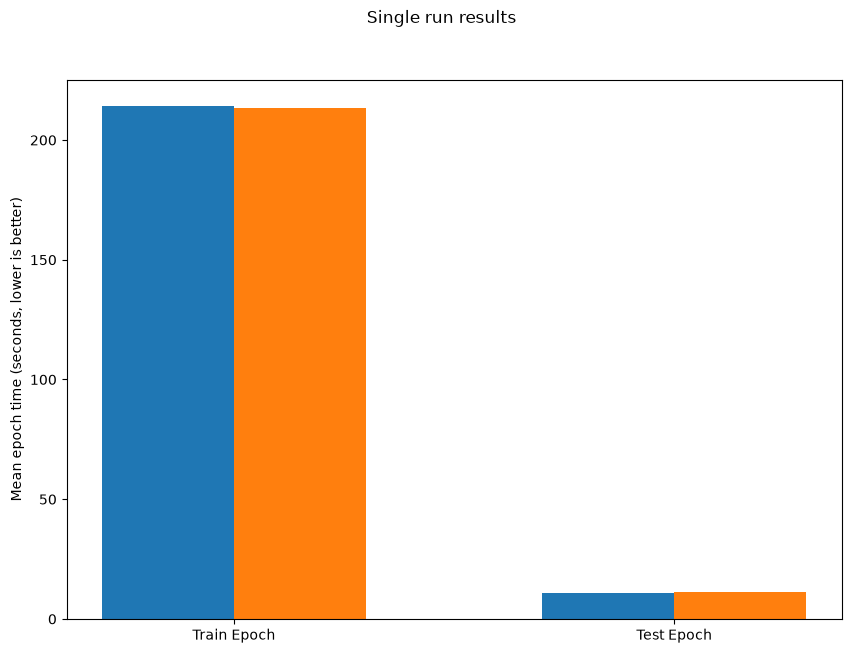

In [23]:
# Create directory for saving figures
import os
dir_to_save_figures_in = "pytorch_2_results/figures/" 
os.makedirs(dir_to_save_figures_in, exist_ok=True)

# Create a save path for the single run results
save_path_multi_run = f"{dir_to_save_figures_in}single_run_{MODEL_NAME}_{DATASET_NAME}_{IMAGE_SIZE}_train_epoch_time.png"
print(f"[INFO] Save path for single run results: {save_path_multi_run}")

# Plot the results and save the figures
plot_mean_epoch_times(non_compiled_results=single_run_no_compile_results_df, 
                      compiled_results=single_run_compile_results_df, 
                      multi_runs=False, 
                      save_path=save_path_multi_run, 
                      save=True)

In [ ]:
# Make a directory for single_run results
import os
pytorch_2_results_dir = "pytorch_2_results"
pytorch_2_single_run_results_dir = f"{pytorch_2_results_dir}/single_run_results"
os.makedirs(pytorch_2_single_run_results_dir, exist_ok=True)

# Create filenames for each of the dataframes
save_name_for_non_compiled_results = f"single_run_non_compiled_results_{DATASET_NAME}_{MODEL_NAME}_{GPU_NAME}.csv"
save_name_for_compiled_results = f"single_run_compiled_results_{DATASET_NAME}_{MODEL_NAME}_{GPU_NAME}.csv"

# Create filepaths to save the results to
single_run_no_compile_save_path = f"{pytorch_2_single_run_results_dir}/{save_name_for_non_compiled_results}"
single_run_compile_save_path = f"{pytorch_2_single_run_results_dir}/{save_name_for_compiled_results}"
print(f"[INFO] Saving non-compiled experiment 1 results to: {single_run_no_compile_save_path}")
print(f"[INFO] Saving compiled experiment 2 results to: {single_run_compile_save_path}")

# Save the results
single_run_no_compile_results_df.to_csv(single_run_no_compile_save_path)
single_run_compile_results_df.to_csv(single_run_compile_save_path)

### Time models across multiple runs

We're going to start by creating three functions for experiments 3 and 4.

Experiment 3: create_and_train_non_compiled_model() - this function will be similar to the workflow we've used for the single runs. We'll put the model creation (via create_model()) and training in a single function so we can call it multiple times (for multiple runs) and measure the time of each run.

Experiment 4: create_compiled_model() - this function will be similar to the create_model() function above, however, it will create a normal PyTorch model and then call torch.compile() on it and return it.

Experiment 4: train_compiled_model() - this function will take in a compiled model and train it in the same way we've been training our models for single runs.

def create_and_train_non_compiled_model(epochs=NUM_EPOCHS, 
                                        learning_rate=LEARNING_RATE, 
                                        disable_progress_bar=False):
    """
    Create and train a non-compiled PyTorch model.
    """
    model, _ = create_model()
    model.to(device)

    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=learning_rate)

    results = train(model=model,
                    train_dataloader=train_dataloader,
                    test_dataloader=test_dataloader,
                    loss_fn=loss_fn,
                    optimizer=optimizer,
                    epochs=epochs,
                    device=device,
                    disable_progress_bar=disable_progress_bar)
    return results

def create_compiled_model():
    """
    Create a compiled PyTorch model and return it.
    """
    model, _ = create_model()
    model.to(device)
    
    compile_start_time = time.time()
    ### New in PyTorch 2.x ###
    compiled_model = torch.compile(model)
    ##########################
    compile_end_time = time.time()

    compile_time = compile_end_time - compile_start_time

    print(f"Time to compile: {compile_time} | Note: The first time you compile your model, the first few epochs will be slower than subsequent runs.")
    return compiled_model

def train_compiled_model(model=compiled_model, 
                         epochs=NUM_EPOCHS, 
                         learning_rate=LEARNING_RATE,
                         disable_progress_bar=False):
    """
    Train a compiled model and return the results.
    """
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(compiled_model.parameters(),
                                 lr=learning_rate)
    
    compile_results = train(model=model,
                            train_dataloader=train_dataloader,
                            test_dataloader=test_dataloader,
                            loss_fn=loss_fn,
                            optimizer=optimizer,
                            epochs=epochs,
                            device=device,
                            disable_progress_bar=disable_progress_bar)
    
    return compile_results

### Experiment 3 - Multiple runs, no compile

Experiment	     Model	    Data	 Epochs	 Batchsize	 Image size	 torch.compile()
3 (multi-run)	ResNet50	CIFAR10	  3x5	  128	           224	   No


In [25]:
def create_and_train_non_compiled_model(epochs=NUM_EPOCHS, 
                                        learning_rate=LEARNING_RATE, 
                                        disable_progress_bar=False):
    """
    Create and train a non-compiled PyTorch model.
    """
    model, _ = create_model()
    model.to(device)

    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=learning_rate)

    results = train(model=model,
                    train_dataloader=train_dataloader,
                    test_dataloader=test_dataloader,
                    loss_fn=loss_fn,
                    optimizer=optimizer,
                    epochs=epochs,
                    device=device,
                    disable_progress_bar=disable_progress_bar)
    return results

def create_compiled_model():
    """
    Create a compiled PyTorch model and return it.
    """
    model, _ = create_model()
    model.to(device)
    
    compile_start_time = time.time()
    ### New in PyTorch 2.x ###
    compiled_model = torch.compile(model)
    ##########################
    compile_end_time = time.time()

    compile_time = compile_end_time - compile_start_time

    print(f"Time to compile: {compile_time} | Note: The first time you compile your model, the first few epochs will be slower than subsequent runs.")
    return compiled_model

def train_compiled_model(model=compiled_model, 
                         epochs=NUM_EPOCHS, 
                         learning_rate=LEARNING_RATE,
                         disable_progress_bar=False):
    """
    Train a compiled model and return the results.
    """
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(compiled_model.parameters(),
                                 lr=learning_rate)
    
    compile_results = train(model=model,
                            train_dataloader=train_dataloader,
                            test_dataloader=test_dataloader,
                            loss_fn=loss_fn,
                            optimizer=optimizer,
                            epochs=epochs,
                            device=device,
                            disable_progress_bar=disable_progress_bar)
    
    return compile_results

In [26]:
# Run non-compiled model for multiple runs
NUM_RUNS = 3
NUM_EPOCHS = 5

# Create an empty list to store multiple run results
non_compile_results_multiple_runs = []

# Run non-compiled model for multiple runs
for i in tqdm(range(NUM_RUNS)):
    print(f"[INFO] Run {i+1} of {NUM_RUNS} for non-compiled model")
    results = create_and_train_non_compiled_model(epochs=NUM_EPOCHS, disable_progress_bar=True)
    non_compile_results_multiple_runs.append(results)

  0%|          | 0/3 [00:00<?, ?it/s]

[INFO] Run 1 of 3 for non-compiled model


/home/reddy/pytorch/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: bgemm_internal_cublaslt error: HIPBLAS_STATUS_NOT_SUPPORTED when calling hipblasLtMatmul with transpose_mat1 n transpose_mat2 t m 2048 n 10 k 32 lda 2048 ldb 10 ldc 2048 abType 0 cType 0 computeType 6 scaleType 0. Will attempt to recover by calling cublas instead. (Triggered internally at /__w/rockrel/rockrel/external-builds/pytorch/pytorch/aten/src/ATen/hip/HIPBlas.cpp:612.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/home/reddy/pytorch/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: bgemm_internal_cublaslt error: HIPBLAS_STATUS_NOT_SUPPORTED when calling hipblasLtMatmul with transpose_mat1 n transpose_mat2 t m 2048 n 10 k 16 lda 2048 ldb 10 ldc 2048 abType 0 cType 0 computeType 6 scaleType 0. Will attempt to recover by calling cublas instead. (Triggered internally at /__w/rockrel/rockrel/external-bui

Epoch: 1 | train_loss: 1.1253 | train_acc: 0.6011 | test_loss: 0.7971 | test_acc: 0.7199 | train_epoch_time: 204.4974 | test_epoch_time: 11.1006
Epoch: 2 | train_loss: 0.6774 | train_acc: 0.7670 | test_loss: 0.6294 | test_acc: 0.7831 | train_epoch_time: 206.9163 | test_epoch_time: 10.9679
Epoch: 3 | train_loss: 0.5170 | train_acc: 0.8220 | test_loss: 0.5325 | test_acc: 0.8145 | train_epoch_time: 207.4863 | test_epoch_time: 10.9766
Epoch: 4 | train_loss: 0.4075 | train_acc: 0.8577 | test_loss: 0.4763 | test_acc: 0.8401 | train_epoch_time: 207.4845 | test_epoch_time: 10.9936


 33%|███▎      | 1/3 [18:09<36:18, 1089.38s/it]

Epoch: 5 | train_loss: 0.3238 | train_acc: 0.8867 | test_loss: 0.4568 | test_acc: 0.8450 | train_epoch_time: 207.5315 | test_epoch_time: 10.9983
[INFO] Run 2 of 3 for non-compiled model
Epoch: 1 | train_loss: 1.0945 | train_acc: 0.6134 | test_loss: 0.7588 | test_acc: 0.7348 | train_epoch_time: 207.5750 | test_epoch_time: 11.0229
Epoch: 2 | train_loss: 0.6805 | train_acc: 0.7650 | test_loss: 0.7017 | test_acc: 0.7624 | train_epoch_time: 207.6110 | test_epoch_time: 10.9970
Epoch: 3 | train_loss: 0.5223 | train_acc: 0.8216 | test_loss: 0.5419 | test_acc: 0.8150 | train_epoch_time: 207.7346 | test_epoch_time: 11.0101
Epoch: 4 | train_loss: 0.4167 | train_acc: 0.8564 | test_loss: 0.4966 | test_acc: 0.8312 | train_epoch_time: 207.3918 | test_epoch_time: 11.0325


 67%|██████▋   | 2/3 [36:22<18:11, 1091.79s/it]

Epoch: 5 | train_loss: 0.3330 | train_acc: 0.8850 | test_loss: 0.4481 | test_acc: 0.8504 | train_epoch_time: 207.7269 | test_epoch_time: 10.9211
[INFO] Run 3 of 3 for non-compiled model
Epoch: 1 | train_loss: 1.1334 | train_acc: 0.5953 | test_loss: 0.8510 | test_acc: 0.7009 | train_epoch_time: 207.9375 | test_epoch_time: 11.0213
Epoch: 2 | train_loss: 0.6923 | train_acc: 0.7604 | test_loss: 0.6500 | test_acc: 0.7738 | train_epoch_time: 207.8545 | test_epoch_time: 10.9928
Epoch: 3 | train_loss: 0.5245 | train_acc: 0.8192 | test_loss: 0.5799 | test_acc: 0.8056 | train_epoch_time: 208.1299 | test_epoch_time: 11.0901
Epoch: 4 | train_loss: 0.4198 | train_acc: 0.8533 | test_loss: 0.5191 | test_acc: 0.8274 | train_epoch_time: 207.7545 | test_epoch_time: 11.0242


100%|██████████| 3/3 [54:38<00:00, 1092.76s/it]

Epoch: 5 | train_loss: 0.3291 | train_acc: 0.8864 | test_loss: 0.4724 | test_acc: 0.8432 | train_epoch_time: 208.2299 | test_epoch_time: 10.9408


In [27]:
# Go through non_compile_results_multiple_runs and create a dataframe for each run then concatenate them together
non_compile_results_dfs = []
for result in non_compile_results_multiple_runs:
    result_df = pd.DataFrame(result)
    non_compile_results_dfs.append(result_df)
non_compile_results_multiple_runs_df = pd.concat(non_compile_results_dfs)

# Get the averages across the multiple runs
non_compile_results_multiple_runs_df = non_compile_results_multiple_runs_df.groupby(non_compile_results_multiple_runs_df.index).mean()
non_compile_results_multiple_runs_df

,train_loss,train_acc,test_loss,test_acc,train_epoch_time,test_epoch_time
0,1.117756,0.603267,0.802295,0.718550,206.669994,11.048248
1,0.683374,0.764109,0.660364,0.773096,207.460583,10.985905
2,0.521253,0.820951,0.551415,0.811701,207.783566,11.025597
3,0.414658,0.855806,0.497336,0.832867,207.543599,11.016769
4,0.328616,0.886023,0.459124,0.846213,207.829431,10.953417


### Experiment 4 - Multiple runs, with compile

Experiment	Model	Data	Epochs	Batch size	Image size	torch.compile()
4 (multi-run)	ResNet50	CIFAR10	3x5	128	224	Yes


In [28]:
# Create compiled model
compiled_model = create_compiled_model()

# Create an empty list to store compiled model results
compiled_results_multiple_runs = []

# Run compiled model for multiple runs
for i in tqdm(range(NUM_RUNS)):
    print(f"[INFO] Run {i+1} of {NUM_RUNS} for compiled model")
    # Train the compiled model (note: the model will only be compiled once and then re-used for subsequent runs)
    results = train_compiled_model(model=compiled_model, epochs=NUM_EPOCHS, disable_progress_bar=True)
    compiled_results_multiple_runs.append(results)

Time to compile: 0.0012791156768798828 | Note: The first time you compile your model, the first few epochs will be slower than subsequent runs.


  0%|          | 0/3 [00:00<?, ?it/s]

[INFO] Run 1 of 3 for compiled model


/tmp/torchinductor_reddy/bj/cbjt5jdajhycdo2clnvizjwng6egwwliad56mukryrqtxdyxqzvt.py:3883: UserWarning: bgemm_internal_cublaslt error: HIPBLAS_STATUS_NOT_SUPPORTED when calling hipblasLtMatmul with transpose_mat1 n transpose_mat2 t m 2048 n 12 k 32 lda 2048 ldb 12 ldc 2048 abType 0 cType 0 computeType 6 scaleType 0. Will attempt to recover by calling cublas instead. (Triggered internally at /__w/rockrel/rockrel/external-builds/pytorch/pytorch/aten/src/ATen/hip/HIPBlas.cpp:612.)
  extern_kernels.mm(buf1, view, out=buf2)
/tmp/torchinductor_reddy/bj/cbjt5jdajhycdo2clnvizjwng6egwwliad56mukryrqtxdyxqzvt.py:3883: UserWarning: bgemm_internal_cublaslt error: HIPBLAS_STATUS_NOT_SUPPORTED when calling hipblasLtMatmul with transpose_mat1 n transpose_mat2 t m 2048 n 12 k 16 lda 2048 ldb 12 ldc 2048 abType 0 cType 0 computeType 6 scaleType 0. Will attempt to recover by calling cublas instead. (Triggered internally at /__w/rockrel/rockrel/external-builds/pytorch/pytorch/aten/src/ATen/hip/HIPBlas.cpp:

Epoch: 1 | train_loss: 1.1339 | train_acc: 0.5962 | test_loss: 0.8997 | test_acc: 0.6848 | train_epoch_time: 200.2624 | test_epoch_time: 9.6854
Epoch: 2 | train_loss: 0.6882 | train_acc: 0.7597 | test_loss: 0.7210 | test_acc: 0.7578 | train_epoch_time: 200.0416 | test_epoch_time: 9.5760
Epoch: 3 | train_loss: 0.5242 | train_acc: 0.8183 | test_loss: 0.5572 | test_acc: 0.8076 | train_epoch_time: 200.0434 | test_epoch_time: 9.6505
Epoch: 4 | train_loss: 0.4183 | train_acc: 0.8551 | test_loss: 0.5256 | test_acc: 0.8251 | train_epoch_time: 200.4286 | test_epoch_time: 9.6656


...

Epoch: 5 | train_loss: 0.3257 | train_acc: 0.8852 | test_loss: 0.4549 | test_acc: 0.8515 | train_epoch_time: 200.0304 | test_epoch_time: 9.7090
[INFO] Run 2 of 3 for compiled model
Epoch: 1 | train_loss: 0.2635 | train_acc: 0.9104 | test_loss: 0.5201 | test_acc: 0.8394 | train_epoch_time: 200.2905 | test_epoch_time: 9.5764
Epoch: 2 | train_loss: 0.1858 | train_acc: 0.9349 | test_loss: 0.5796 | test_acc: 0.8315 | train_epoch_time: 199.8716 | test_epoch_time: 9.7319
Epoch: 3 | train_loss: 0.1399 | train_acc: 0.9509 | test_loss: 0.5105 | test_acc: 0.8542 | train_epoch_time: 199.9634 | test_epoch_time: 9.6337
Epoch: 4 | train_loss: 0.1144 | train_acc: 0.9600 | test_loss: 0.5988 | test_acc: 0.8335 | train_epoch_time: 201.0627 | test_epoch_time: 9.6399


 67%|██████▋   | 2/3 [34:58<17:29, 1049.28s/it]

Epoch: 5 | train_loss: 0.0930 | train_acc: 0.9672 | test_loss: 0.5956 | test_acc: 0.8482 | train_epoch_time: 199.9932 | test_epoch_time: 9.6478
[INFO] Run 3 of 3 for compiled model
Epoch: 1 | train_loss: 0.0914 | train_acc: 0.9688 | test_loss: 0.6096 | test_acc: 0.8519 | train_epoch_time: 200.6352 | test_epoch_time: 9.6644
Epoch: 2 | train_loss: 0.0747 | train_acc: 0.9745 | test_loss: 0.5927 | test_acc: 0.8514 | train_epoch_time: 200.3753 | test_epoch_time: 9.6632
Epoch: 3 | train_loss: 0.0681 | train_acc: 0.9762 | test_loss: 0.6233 | test_acc: 0.8516 | train_epoch_time: 200.7194 | test_epoch_time: 9.6303
Epoch: 4 | train_loss: 0.0612 | train_acc: 0.9785 | test_loss: 0.6704 | test_acc: 0.8433 | train_epoch_time: 200.4269 | test_epoch_time: 9.7255


100%|██████████| 3/3 [52:29<00:00, 1049.73s/it]

Epoch: 5 | train_loss: 0.0556 | train_acc: 0.9810 | test_loss: 0.6635 | test_acc: 0.8531 | train_epoch_time: 200.2101 | test_epoch_time: 9.6160


In [29]:
# Go through compile_results_multiple_runs and create a dataframe for each run then concatenate them together
compile_results_dfs = []
for result in compiled_results_multiple_runs:
    result_df = pd.DataFrame(result)
    compile_results_dfs.append(result_df)
compile_results_multiple_runs_df = pd.concat(compile_results_dfs)

# Get the averages across the multiple runs
compile_results_multiple_runs_df = compile_results_multiple_runs_df.groupby(compile_results_multiple_runs_df.index).mean() # .index = groupby the epoch number
compile_results_multiple_runs_df

,train_loss,train_acc,test_loss,test_acc,train_epoch_time,test_epoch_time
0,0.496255,0.825143,0.676497,0.792033,200.396019,9.642086
1,0.316232,0.889682,0.631092,0.813565,200.096151,9.657026
2,0.244052,0.915114,0.563684,0.837826,200.242046,9.638167
3,0.197972,0.931202,0.598258,0.833932,200.639366,9.676992
4,0.158094,0.944458,0.571318,0.850972,200.077892,9.657615


Mean train epoch time difference: -3.455% (negative means faster)
Mean test epoch time difference: -12.281% (negative means faster)


NameError: name 'gpu_name' is not defined

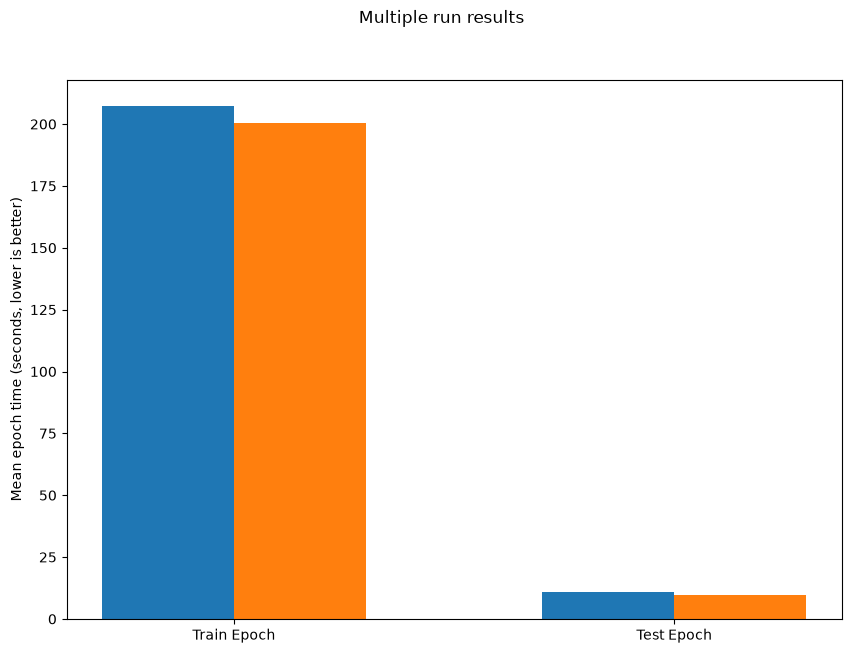

In [31]:
# Create a directory to save the multi-run figure to 
os.makedirs("pytorch_2_results/figures", exist_ok=True)

# Create a path to save the figure for multiple runs
save_path_multi_run = f"pytorch_2_results/figures/multi_run__{MODEL_NAME}_{DATASET_NAME}_{IMAGE_SIZE}_train_epoch_time.png"

# Plot the mean epoch times for experiment 3 and 4
plot_mean_epoch_times(non_compiled_results=non_compile_results_multiple_runs_df, 
                      compiled_results=compile_results_multiple_runs_df, 
                      multi_runs=True, 
                      num_runs=NUM_RUNS, 
                      save_path=save_path_multi_run, 
                      save=True)

In [ ]:
# Make a directory for multi_run results
import os
pytorch_2_results_dir = "pytorch_2_results"
pytorch_2_multi_run_results_dir = f"{pytorch_2_results_dir}/multi_run_results"
os.makedirs(pytorch_2_multi_run_results_dir, exist_ok=True)

# Create filenames for each of the dataframes
save_name_for_multi_run_non_compiled_results = f"multi_run_non_compiled_results_{NUM_RUNS}_runs_{DATASET_NAME}_{MODEL_NAME}_{GPU_NAME}.csv"
save_name_for_multi_run_compiled_results = f"multi_run_compiled_results_{NUM_RUNS}_runs_{DATASET_NAME}_{MODEL_NAME}_{GPU_NAME}.csv"

# Create filepaths to save the results to
multi_run_no_compile_save_path = f"{pytorch_2_multi_run_results_dir}/{save_name_for_non_compiled_results}"
multi_run_compile_save_path = f"{pytorch_2_multi_run_results_dir}/{save_name_for_compiled_results}"
print(f"[INFO] Saving experiment 3 non-compiled results to: {multi_run_no_compile_save_path}")
print(f"[INFO] Saving experiment 4 compiled results to: {multi_run_compile_save_path}")

# Save the results
non_compile_results_multiple_runs_df.to_csv(multi_run_no_compile_save_path)
compile_results_multiple_runs_df.to_csv(multi_run_compile_save_path)